In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/loan-train.csv')

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [ ]:
missing=pd.DataFrame({
    "Count of null": df.isnull().sum(),
    "Percentage of null":(df.isnull().sum()/len(df))*100
})


In [ ]:
missing

,Count of null,Percentage of null
Loan_ID,0,0.000000
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Education,0,0.000000
Self_Employed,32,5.211726
ApplicantIncome,0,0.000000
CoapplicantIncome,0,0.000000
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130


<Axes: xlabel='count', ylabel='Loan_Status'>

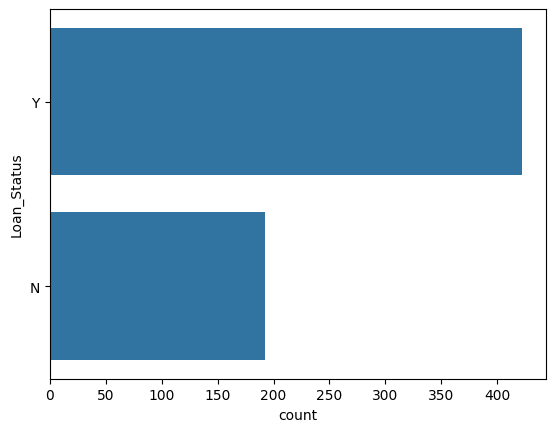

In [ ]:
sns.countplot(df['Loan_Status'])

In [ ]:
counts=df['Loan_Status'].value_counts()  # .value_count for find ki value kitni bar aai hai

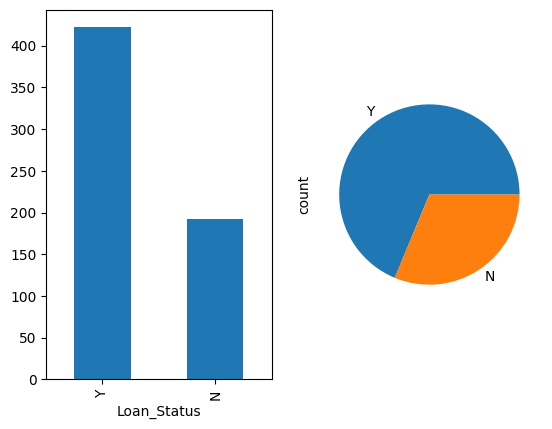

In [ ]:
def distribution(column):
  counts=column.value_counts()

  plt.subplot(1,2,1)
  counts.plot(kind='bar')

  plt.subplot(1,2,2)
  counts.plot(kind='pie')
distribution(df['Loan_Status'])

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

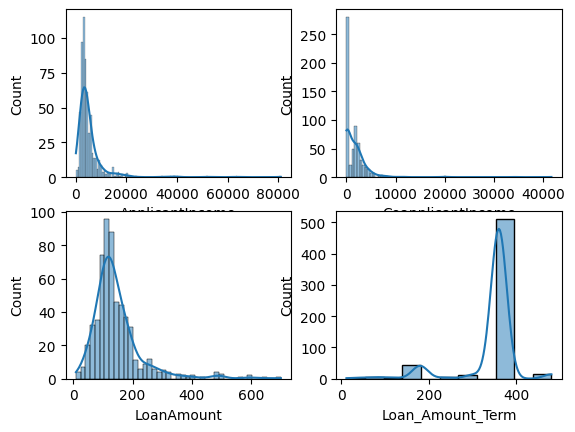

In [ ]:
#univariate analysis   (single column ka distribution)
plt.subplot(2,2,1)
sns.histplot(df['ApplicantIncome'],kde=True)

plt.subplot(2,2,2)
sns.histplot(df['CoapplicantIncome'],kde=True)

plt.subplot(2,2,3)
sns.histplot(df['LoanAmount'],kde=True)

plt.subplot(2,2,4)
sns.histplot(df['Loan_Amount_Term'],kde=True)




In [ ]:
# mean >median >mode  right skewed
# mean<median<mode left skewed

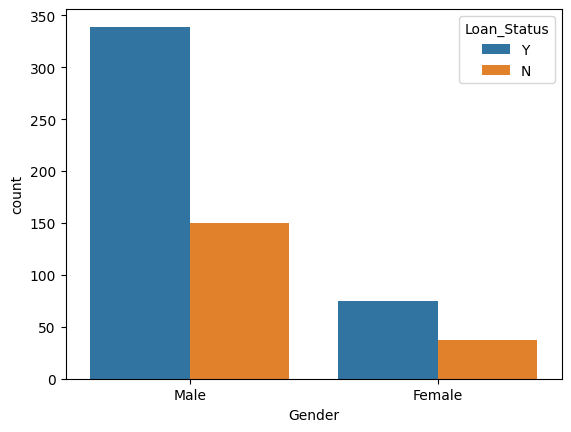

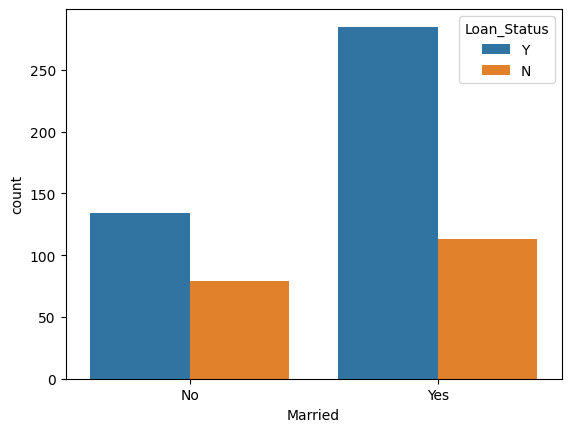

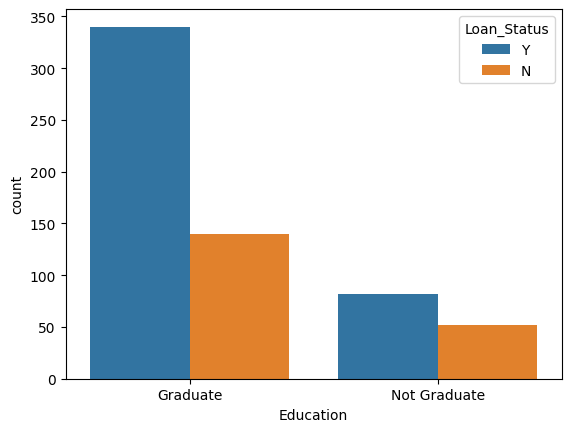

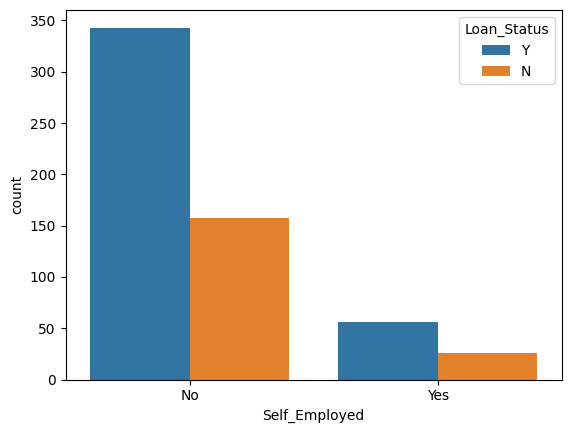

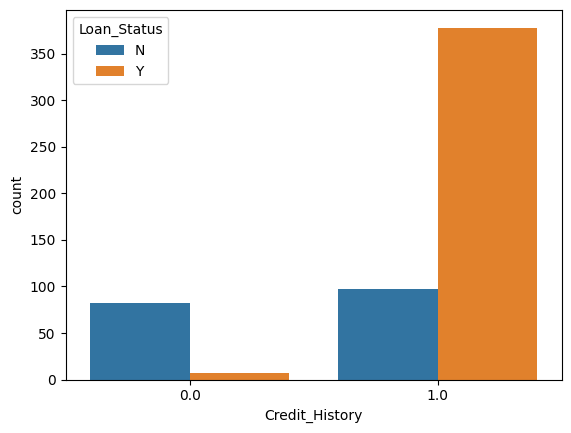

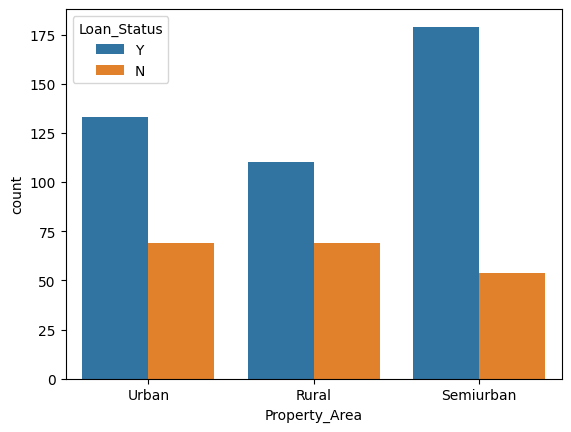

In [ ]:
#Bivariate Analysis  (do column ka distribution )(one continues and one categoral (target columnb))
# categorical features vs loan_staus


cat_features=['Gender','Married','Education','Self_Employed','Credit_History','Property_Area']
for i in cat_features:
  sns.countplot(x=i,hue='Loan_Status',data=df)
  plt.show()


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df_copy=df.copy()

<Axes: >

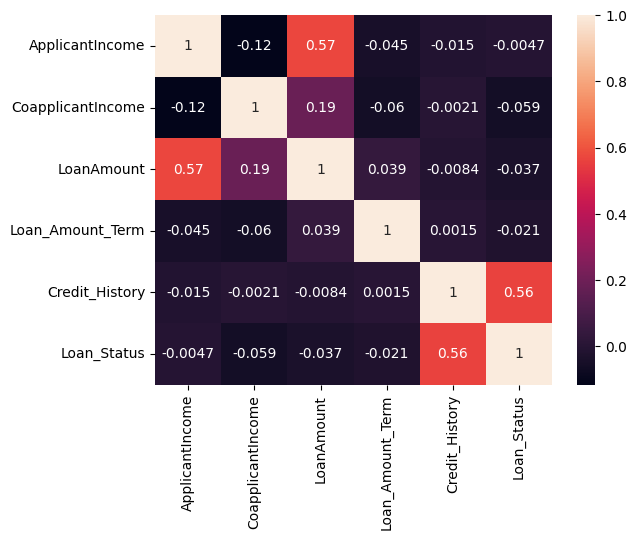

In [ ]:
df_copy['Loan_Status']=df_copy['Loan_Status'].map({'Y':1,'N':0})

sns.heatmap(df_copy.select_dtypes(include=[np.number]).corr(),annot=True)

<Axes: xlabel='Loan_Status', ylabel='count'>

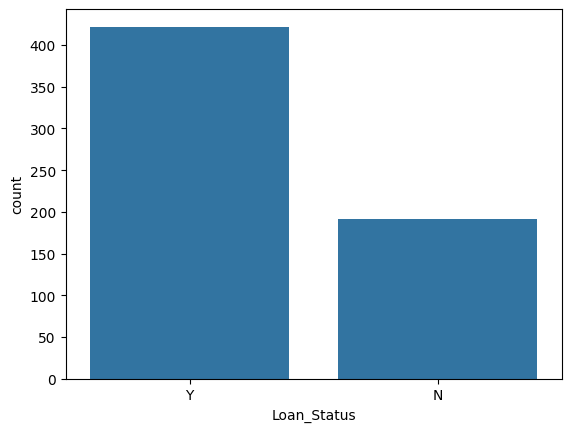

In [ ]:
sns.countplot(x='Loan_Status',data=df)

In [ ]:
#checking null values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
#filling up categorical null values
def handle_cat_null(df):
  cat_cols=['Gender','Married','Dependents','Self_Employed','Credit_History']
  for i in cat_cols:
    df_copy[i].fillna(df_copy[i].mode()[0],inplace=True)
handle_cat_null(df)

/tmp/ipykernel_20207/920419537.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy[i].fillna(df_copy[i].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


<Axes: xlabel='ApplicantIncome', ylabel='Count'>

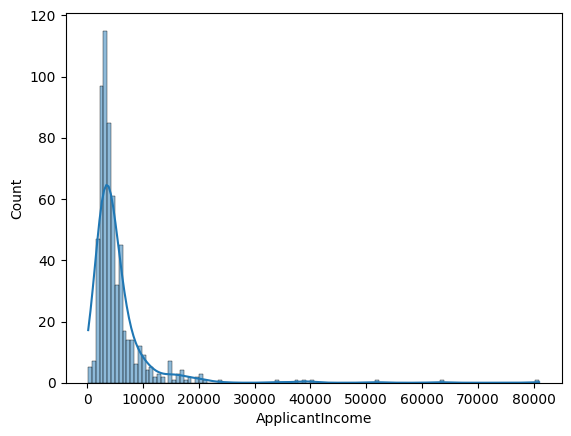

In [ ]:
sns.histplot(df['ApplicantIncome'],kde=True)

In [ ]:
#check skweness
df['ApplicantIncome'].mean() , df['ApplicantIncome'].median()

(np.float64(5403.459283387622), 3812.5)

In [ ]:
#check skweness
# histplot
# boxplot
# mean>median   - right
# mean<median    - left skwed
# use .skew()
# -0.5 to +0.5 centralize

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

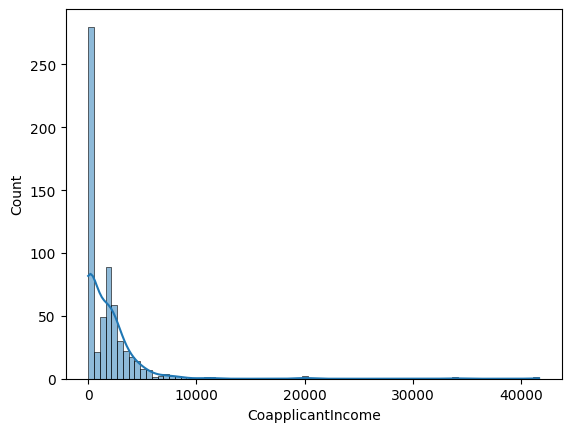

In [ ]:
sns.histplot(df['CoapplicantIncome'],kde=True)
#

<Axes: xlabel='LoanAmount', ylabel='Count'>

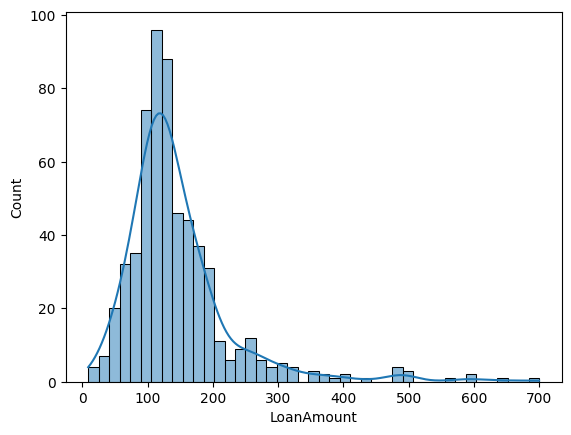

In [ ]:
sns.histplot(df['LoanAmount'],kde=True)

In [ ]:
def numeric_null(df):
  num_cols=['LoanAmount','Loan_Amount_Term']
  for i in num_cols:
    df_copy[i].fillna(df_copy[i].mean(),inplace=True)
numeric_null(df)

/tmp/ipykernel_20207/4111949323.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy[i].fillna(df_copy[i].mean(),inplace=True)


In [ ]:
df_copy.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df_copy.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,1


In [ ]:
#performing encoding
df_enc=df_copy.copy()

In [ ]:
df_enc.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,1


In [ ]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


In [ ]:
df_enc['Dependents'].replace('3+',3,inplace=True)

/tmp/ipykernel_20207/1601949970.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_enc['Dependents'].replace('3+',3,inplace=True)


In [ ]:
df_enc['Dependents']=pd.to_numeric(df_enc['Dependents'])

In [ ]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 62.5+ KB


In [ ]:
df_enc.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
cat_cols=[ 'Gender', 'Married', 'Education',
       'Self_Employed','Property_Area']

In [ ]:
df_enc=pd.get_dummies(df_enc,columns=cat_cols)

In [ ]:
df_enc

,Loan_ID,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,0,5849,0.0,146.412162,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True
1,LP001003,1,4583,1508.0,128.000000,360.0,1.0,0,False,True,False,True,True,False,True,False,True,False,False
2,LP001005,0,3000,0.0,66.000000,360.0,1.0,1,False,True,False,True,True,False,False,True,False,False,True
3,LP001006,0,2583,2358.0,120.000000,360.0,1.0,1,False,True,False,True,False,True,True,False,False,False,True
4,LP001008,0,6000,0.0,141.000000,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,2900,0.0,71.000000,360.0,1.0,1,True,False,True,False,True,False,True,False,True,False,False
610,LP002979,3,4106,0.0,40.000000,180.0,1.0,1,False,True,False,True,True,False,True,False,True,False,False
611,LP002983,1,8072,240.0,253.000000,360.0,1.0,1,False,True,False,True,True,False,True,False,False,False,True
612,LP002984,2,7583,0.0,187.000000,360.0,1.0,1,False,True,False,True,True,False,True,False,False,False,True


In [ ]:
x=df_enc.drop(['Loan_ID','Loan_Status'],axis=1)
y=df_enc['Loan_Status']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
se=StandardScaler()
x_train=se.fit_transform(x_train)
x_test=se.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model=LogisticRegression()

In [ ]:
model

LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
accuracy_score(y_test,y_pred)

0.7886178861788617

In [ ]:
y_pred_train=model.predict(x_train)

In [ ]:
accuracy_score(y_train,y_pred_train)

0.8207739307535642

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [ ]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [ ]:
joblib.dump(model, "model.pkl")
joblib.dump(x.columns.tolist(), "features.pkl")

['features.pkl']